# Example notebook of a Sample QC analysis

The present notebook serves as a guide of how use the `IDEAL-GENOM-QC` library to perform a sample quality control. We intend to show a possible use, because each user can adapt it to its particular needs.

In this notebook the procedure to perform the sample quality control is more detailed so the user can get a deeper understanding of all the steps executed in this part of the pipeline.

Let us import the required libraries.

In [13]:
import sys
import os
import time, gc, psutil

import pandas as pd

from pathlib import Path

# add parent directory to path
library_path = os.path.abspath('..')
if library_path not in sys.path:
    sys.path.append(library_path)

library_path = Path(library_path)

from ideal_genom.qc.sample_qc import SampleQC, SampleQCReport, SampleQCCleanUp

In the next cell the path variables associated with the project are set.

Moreover, since each user can have a slightly different choices for the LD regions, the user can provide its own file. Nevertheless, we provide the functionality of automatically fetching high LD regions for builts **GRCh37** and **GRCH38**.

Let us set the path parameters to execute the sample QC.

In [4]:
DATA_PATH = library_path / 'ideal_genom' / 'data'

test_data = DATA_PATH / 'test_data'
inputData = test_data / 'inputData'
ouputData = test_data / 'outputData'
config    = test_data / 'config'

In [5]:
input_path = inputData
input_name = '1kG_phase3_GRCh38_updated'
output_path=  ouputData
output_name= '1KG_GRCh38_sample_qc'
high_ld_file = Path('path/to/ld-regions/file') # if not available, set to None

In the next cell we define a dictionary containing the parameters to execute the sample QC pipeline.

The explanation of the parameters is the following:

1. `rename_snp`: if `True` the pipeline will change the SNPs identifiers to the format chr_pos_a1_a2.
2. `hh_to_missing`: if `True` the pipeline sets heterozygous haploid to missing, check **PLINK1.9** command `--set-hh-missing` for more details.
3. `use_kingship`: if `True` the pipeline will use the kingship estimator for duplicates and relatedness check.
4. `ind_pair`: parameters of **PLINK1.9** `--indep-pairwise`.
5. `mind`: parameter of **PLINK1.9** `--mind`.
6. `sex_check`: parameters of **PLINK1.9** `--sex-check`.
7. `maf`: minor allele frequency, parameter of **PLINK1.9** `--maf`.
8. `het_deviation`: values of deviation from heterozigosity.
9. `kingship`: parameters of **PLINK1.9** `--king-cutoff`.
10. `ibd_threshold`: threshold to filter samples according to IBD.

In [11]:
sample_params = {
    "rename_snp"   : True,
    "hh_to_missing": True,
    "use_kinship" : True,
    "ind_pair"     : [20000, 2000, 0.5],
    "mind"         : 0.00025,
    "sex_check"    : [0.5, 0.8],
    "maf"          : 0.01,
    "het_deviation": 1.5,
    "kinship"     : 0.354,
    "ibd_threshold": 0.185
}

Initialize the class `SampleQC`.

In [7]:
sample_qc = SampleQC(
    input_path      =input_path,
    input_name      =input_name,
    output_path     =output_path,
    output_name     =output_name,
    high_ld_regions_file    =high_ld_file,
    build           ='38', # '38' it is the default value 
)

INFO:ideal_genom.qc.sample_qc:High LD file not found at path/to/ld-regions/file
INFO:ideal_genom.qc.sample_qc:High LD file will be fetched from the package
INFO:ideal_genom.qc.sample_qc:High LD file fetched from the package and saved at /home/luis/CGE/ideal-genom-qc/ideal_genom/data/ld_regions_files/high-LD-regions_GRCH38.txt


Execute the pipeline steps of the sample quality control. Since the ides of a notebook is to build a more interactive interface, the next steps do not drop the samples failing QC, they just find the samples.

In [12]:
sample_qc.execute_sample_qc_pipeline(sample_params=sample_params)

INFO:ideal_genom.qc.sample_qc:Starting Sample Quality Control Pipeline
INFO:ideal_genom.qc.sample_qc:STEP: Rename SNPs. `rename` set to True. Renaming SNPs in the study data to the format chr_pos_a1_a2
INFO:ideal_genom.core.executor:Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated --set-all-var-ids @:#:$r:$a --threads 30 --memory 36552 --make-bed --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated-renamed


Rename SNPs to chr:pos:ref:alt.
PLINK v2.0.0-a.6.26LM AVX2 Intel (26 Oct 2025)      cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated-renamed.log.
Options in effect:
  --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated
  --make-bed
  --memory 36552
  --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated-renamed
  --set-all-var-ids @:#:$r:$a
  --threads 30

Start time: Mon Jan 19 14:43:26 2026
63863 MiB RAM detected, ~55843 available; reserving 36552 MiB for main
workspace.
Using up to 30 threads (change this with --threads).
3202 samples (1603 females, 1598 males, 1 ambiguous; 2583 founders) loaded from
/home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated.fam.
64068184 variants loaded from
/hom

INFO:ideal_genom.core.executor:Command completed successfully
INFO:ideal_genom.qc.sample_qc:Successfully completed step: rename SNPs


done.
End time: Mon Jan 19 14:44:21 2026


INFO:ideal_genom.qc.sample_qc:Memory usage after rename SNPs: 12.6%
INFO:ideal_genom.qc.sample_qc:STEP: Convert haploid genotypes to missing values. `hh_to_missing` set to True. Converting haploid genotypes to missing values in the study data
INFO:ideal_genom.qc.sample_qc:STEP: Convert haploid genotypes to missing values
INFO:ideal_genom.core.executor:Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated-renamed --set-invalid-haploid-missing --make-bed --threads 30 --memory 36512 --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated-hh-missing


...

INFO:ideal_genom.qc.sample_qc:Memory usage after get_fail_samples: 7.9%
INFO:ideal_genom.qc.sample_qc:STEP: Drop samples that failed quality control checks
INFO:ideal_genom.qc.sample_qc:Binary file name: 1kG_phase3_GRCh38_updated-hh-missing
INFO:ideal_genom.core.executor:Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated-hh-missing --remove /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/outputData/sample_qc_results/fail_samples/fail_samples.txt --make-bed --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/outputData/sample_qc_results/clean_files/1KG_GRCh38_sample_qc


Drop samples that failed quality control.
PLINK v2.0.0-a.6.26LM AVX2 Intel (26 Oct 2025)      cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/outputData/sample_qc_results/clean_files/1KG_GRCh38_sample_qc.log.
Options in effect:
  --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/inputData/1kG_phase3_GRCh38_updated-hh-missing
  --make-bed
  --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/outputData/sample_qc_results/clean_files/1KG_GRCh38_sample_qc
  --remove /home/luis/CGE/ideal-genom-qc/ideal_genom/data/test_data/outputData/sample_qc_results/fail_samples/fail_samples.txt

Start time: Mon Jan 19 15:29:18 2026
63863 MiB RAM detected, ~58827 available; reserving 31931 MiB for main
workspace.
Using up to 32 threads (change this with --threads).
3202 samples (1603 females, 1598 males, 1 ambiguous; 2583 founders) loaded from
/home/luis

INFO:ideal_genom.core.executor:Command completed successfully
INFO:ideal_genom.qc.sample_qc:Successfully completed step: drop_fail_samples


done.
End time: Mon Jan 19 15:30:05 2026


INFO:ideal_genom.qc.sample_qc:Memory usage after drop_fail_samples: 8.2%
INFO:ideal_genom.qc.sample_qc:Sample Quality Control Pipeline completed successfully


In [14]:
report = SampleQCReport(
    output_path=sample_qc.plots_dir
)

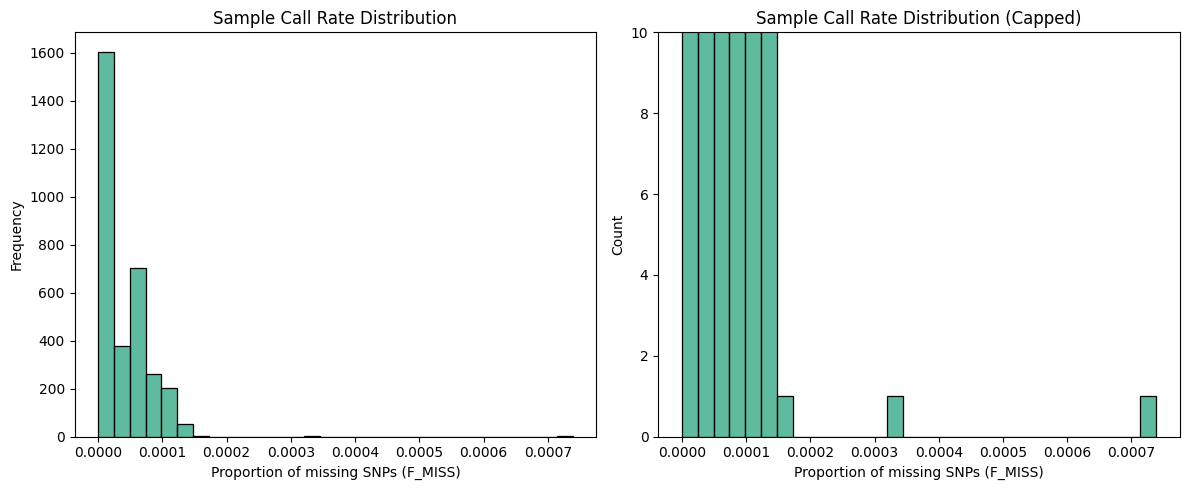

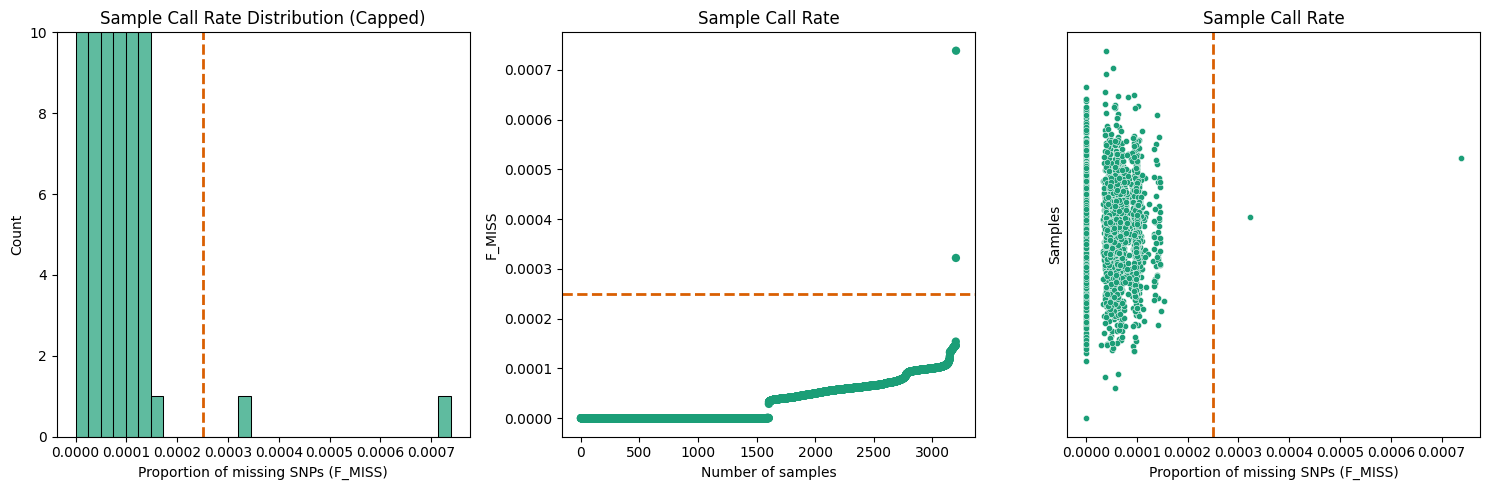

INFO:ideal_genom.qc.sample_qc:Call rate report done


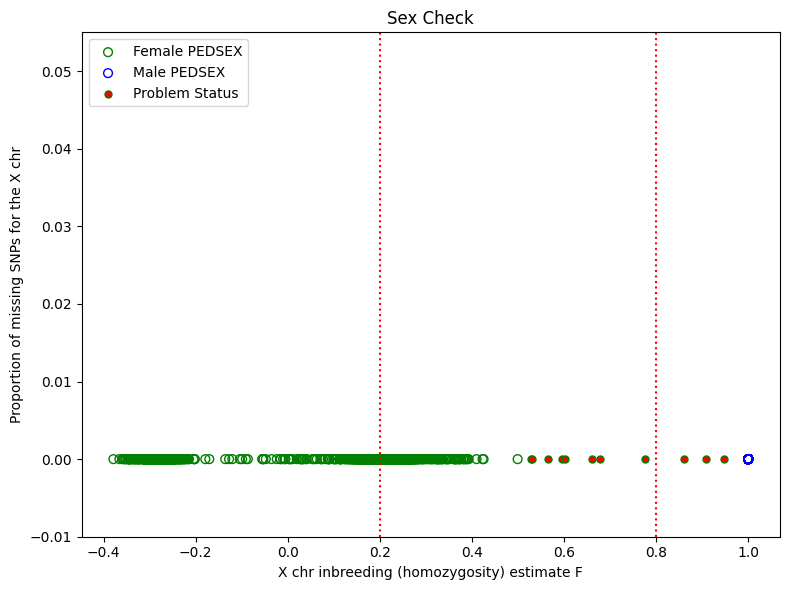

INFO:ideal_genom.qc.sample_qc:Sex check report done


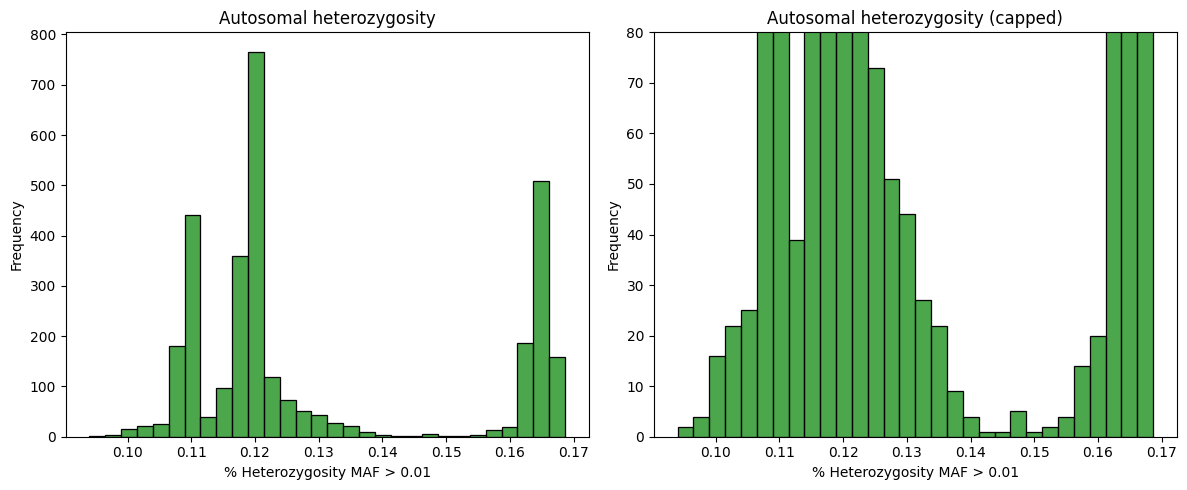

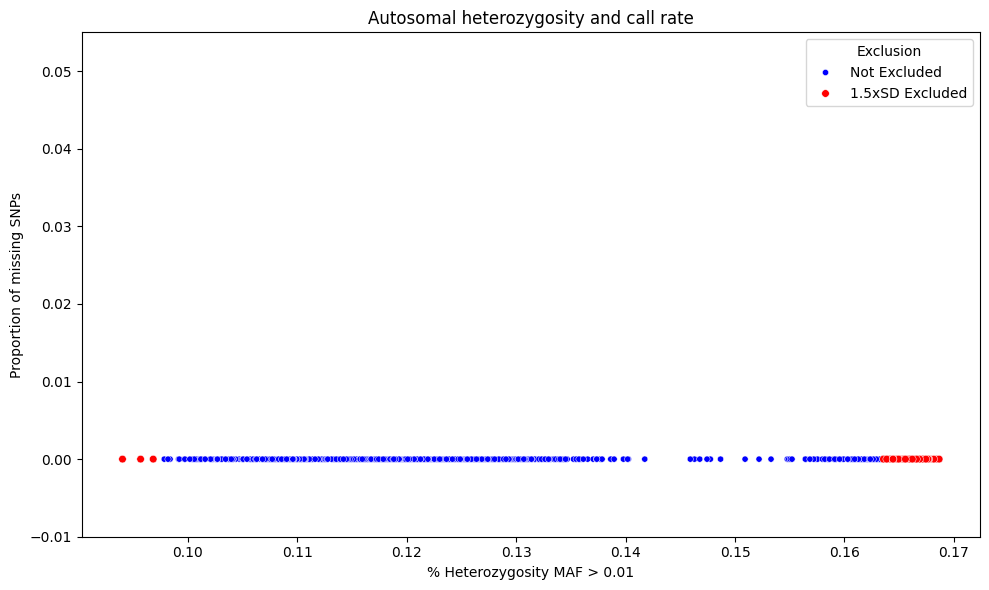

INFO:ideal_genom.qc.sample_qc:Heterozygosity rate check done for MAF > 0.01


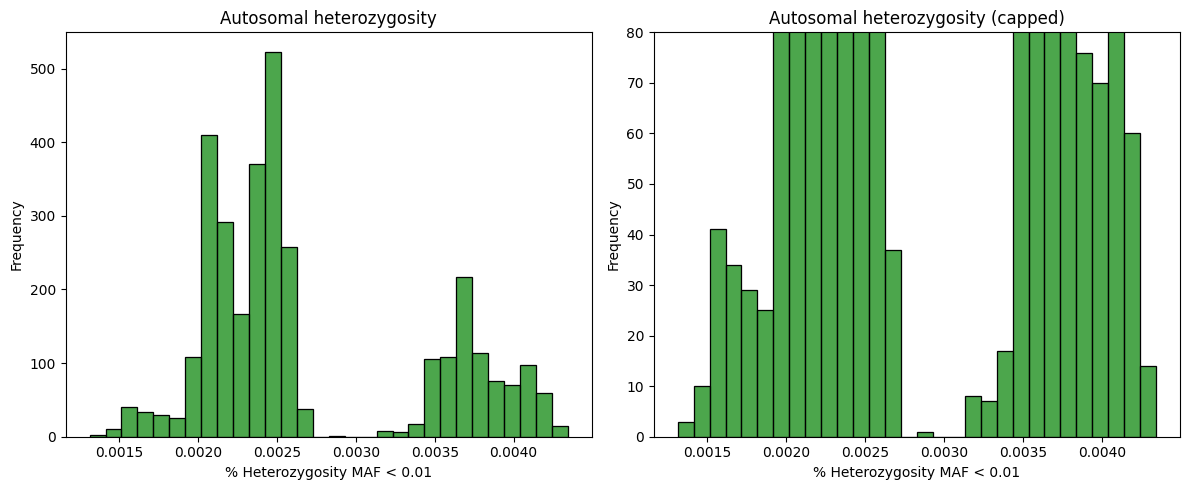

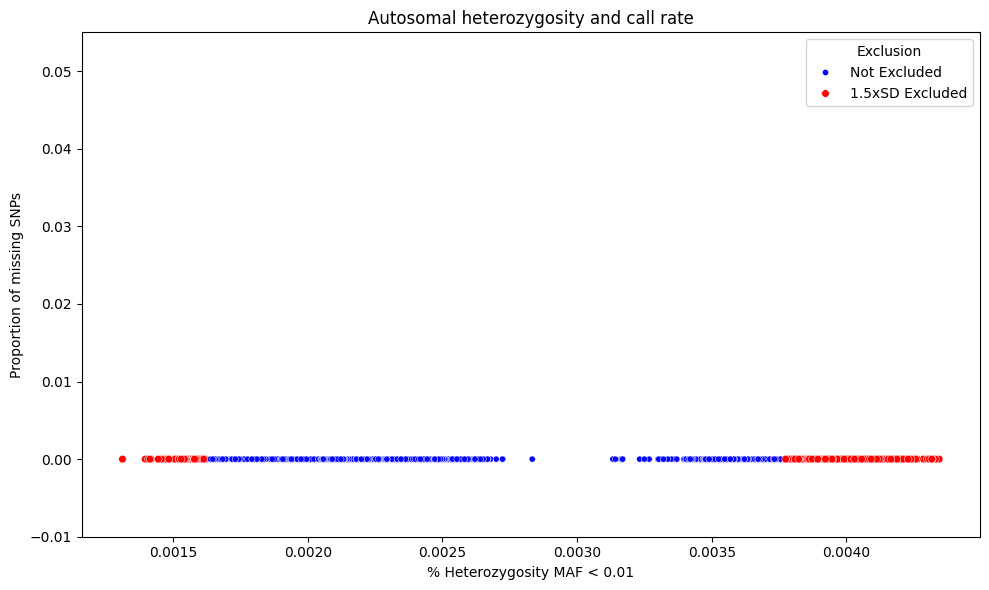

INFO:ideal_genom.qc.sample_qc:Heterozygosity rate check done for MAF < 0.01


In [ ]:
report.report_sample_qc(
    call_rate_smiss     =sample_qc.call_rate_miss,
    sexcheck_miss       =sample_qc.sexcheck_miss,
    xchr_miss           =sample_qc.xchr_miss,
    maf_greater_het     =sample_qc.maf_greater_het,
    maf_less_het        =sample_qc.maf_less_het,
    maf_greater_smiss   =sample_qc.maf_greater_smiss,
    maf_less_smiss      =sample_qc.maf_less_smiss,
    genome              =None,
    generate_ibd_report =False,
    f_coeff_thresholds  =[0.5, 0.8],
    call_rate_thres     =0.00025, 
    std_deviation_het   =1.5, 
    maf_het             =0.01, 
)

Here a small dashboard with a report of the call rate missingness is shown. The cap on the Y-axis can be selected without re-running the whole pipeline, so it can be selected according to each user need. Moreover, the plots could help to choose the best call rate threshold according to the data.

Now, the samples failing sex check are collected and a plot is shown where the user can check the number of problematic samples.

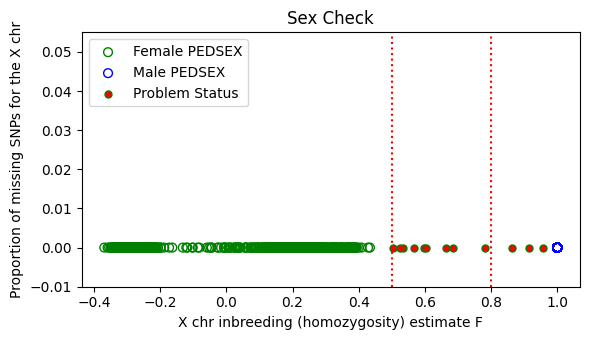

In [9]:
fail_sexcheck = sample_qc.report_sex_check(
            directory          =sample_qc.results_dir, 
            sex_check_filename =sample_qc.output_name+'-sexcheck.sexcheck', 
            xchr_imiss_filename=output_name+'-xchr-missing.imiss',
            f_coeff_thresholds=sample_params['sex_check'],
            plots_dir          =sample_qc.plots_dir,
            format='svg',
            fig_size=(6,3.5)
        )

Here a small dashboard with a report of the heterozigosity is shown. The cap on the Y-axis can be selected without re-running the whole pipeline, so it can be selected according to each user need. Moreover, the plots could help to choose a different deviation from the mean of the heterozigosity rate. Notice that the analysis has been divided for SNPs having a MAF of less than 1% and those above that threshold.

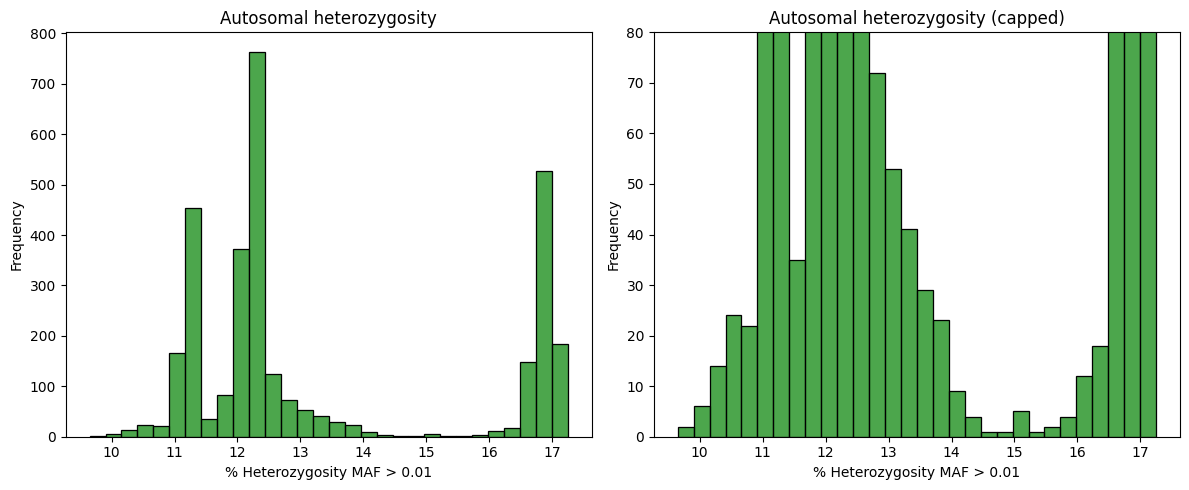

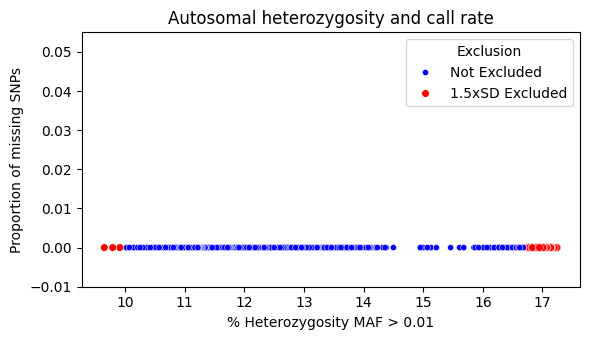

In [8]:
fail_het_greater = sample_qc.report_heterozygosity_rate(
            directory           = sample_qc.results_dir, 
            summary_ped_filename= 'Summary-'+sample_qc.output_name+'-chr1-22-mafgreater-recode.ped', 
            autosomal_filename  = sample_qc.output_name+'-chr1-22-mafgreater-missing.imiss', 
            std_deviation_het   = sample_params['het_deviation'],
            maf                 = sample_params['maf'],
            split               = '>',
            plots_dir           = sample_qc.plots_dir,
            format='svg',
            scatter_fig_size=(6, 3.5),
        )

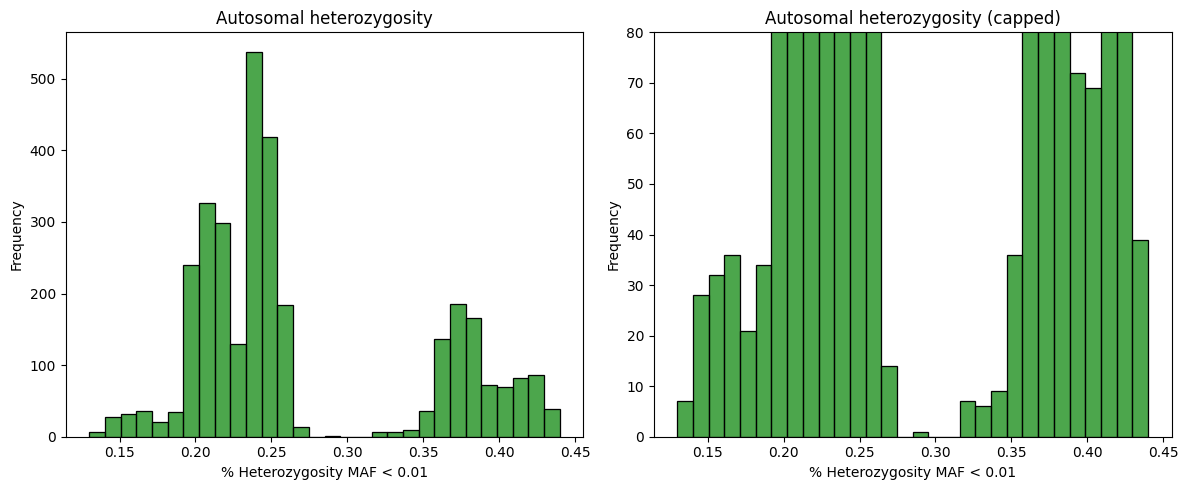

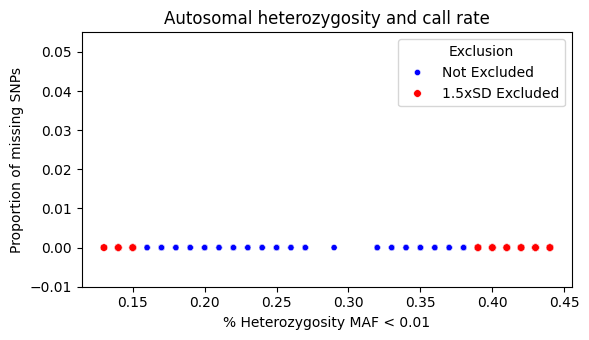

In [10]:
fail_het_gless= sample_qc.report_heterozygosity_rate(
            directory           = sample_qc.results_dir, 
            summary_ped_filename= 'Summary-'+sample_qc.output_name+'-chr1-22-mafless-recode.ped', 
            autosomal_filename  = sample_qc.output_name+'-chr1-22-mafless-missing.imiss', 
            std_deviation_het   = sample_params['het_deviation'],
            maf                 = sample_params['maf'],
            split               = '<',
            plots_dir           = sample_qc.plots_dir,
            format='svg',
            scatter_fig_size=(6, 3.5)
        )

In [ ]:

if sample_qc.use_king:
    fail_dup_relatednes = pd.read_csv(
                sample_qc.kinship_miss,
                sep=r'\s+',
                engine='python'
            )

    # filter samples that failed duplicates and relatedness check
    fail_dup_relatednes.columns = ['FID', 'IID']
    fail_dup_relatednes['Failure'] = 'Duplicates and relatedness'

In [ ]:
if not sample_params['use_kingship']:

    sample_qc.use_king = False

    fail_dup_relatednes = sample_qc.report_ibd_analysis(ibd_threshold=0.185)

    fail_dup_relatednes

All failing samples are collected and concatenated in a single pandas DataFrame and saved. A summary of the amount of samples failing each step is shown. 

In [ ]:
df_fails = pd.concat(
    [fail_call_rate, fail_sexcheck, fail_het_greater, fail_het_gless, fail_dup_relatednes],
    ignore_index=True
)

total_fails = df_fails.shape[0]
duplicates = df_fails.duplicated(subset=['FID', 'IID']).sum()
summary = df_fails['Failure'].value_counts().reset_index()

df_fails = df_fails.drop_duplicates(subset=['FID', 'IID'])

df_fails.to_csv(
    os.path.join(sample_qc.fails_dir, 'fail_samples.txt'), sep='\t',
    index=False
)

In [ ]:
summary

In [ ]:
print('Total samples failing QC: ', total_fails)
print('Number of duplicated samples: ', duplicates)
print('Unique samples failing QC: ', total_fails-duplicates)

Finally, the failing samples are dropped and cleaned `PLINK` files are generated.

In [ ]:
sample_qc.execute_drop_samples()

Some intermediate files are deleted to save space.

In [ ]:
sample_qc.clean_input_folder()
sample_qc.clean_result_folder()